In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving train.csv to train.csv


In [ ]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [ ]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [ ]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [ ]:
X_train.tail()

,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN
168,NaN,25.9250,NaN


missing value ko existing non-missing values me se randomly pick karke replace karna.

In [ ]:
# For X_train
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

# For X_test
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values


In [ ]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([33.  , 28.  , 31.  , 30.  ,  9.  , 16.  , 19.  , 33.  , 15.  ,
       28.  , 16.  , 28.  , 38.  , 28.  , 16.  , 32.  , 30.  , 14.  ,
       47.  , 32.  , 31.  ,  0.75, 70.5 , 23.  , 40.  , 25.  , 54.  ,
       61.  , 51.  , 22.  , 28.  , 35.  , 34.  , 20.  ,  3.  , 35.  ,
        4.  , 36.  , 27.  ,  3.  , 58.  , 15.  , 44.  , 24.  , 32.5 ,
       33.  , 18.  , 40.  ,  3.  , 18.  , 52.  , 19.  , 31.  , 42.  ,
       23.  , 17.  ,  5.  ,  4.  , 27.  , 44.  , 27.  , 17.  , 70.  ,
       21.  , 25.  , 19.  , 26.  , 30.  , 19.  ,  8.  , 39.  , 29.  ,
       21.  , 36.  , 62.  , 35.  , 19.  , 26.  , 51.  , 21.  , 19.  ,
       19.  , 22.  , 20.  , 14.  , 28.  , 32.  , 20.  , 49.  , 25.  ,
       21.  , 30.  , 56.  , 27.  , 27.  , 43.  , 21.  , 28.  , 28.  ,
       39.  , 42.  , 21.  , 22.  , 16.  , 31.  , 22.  ,  9.  , 33.  ,
       39.  , 60.  , 45.  , 22.  ,  2.  , 60.  , 43.  , 30.  , 23.  ,
       42.  , 49.  , 50.  , 19.  , 18.  , 16.  , 48.  , 26.  , 51.  ,
       34.  , 36.  ,

In [ ]:
X_train['Age'].isnull().sum()

np.int64(148)

In [ ]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,30.0
493,71.0,49.5042,71.0
527,NaN,221.7792,46.0


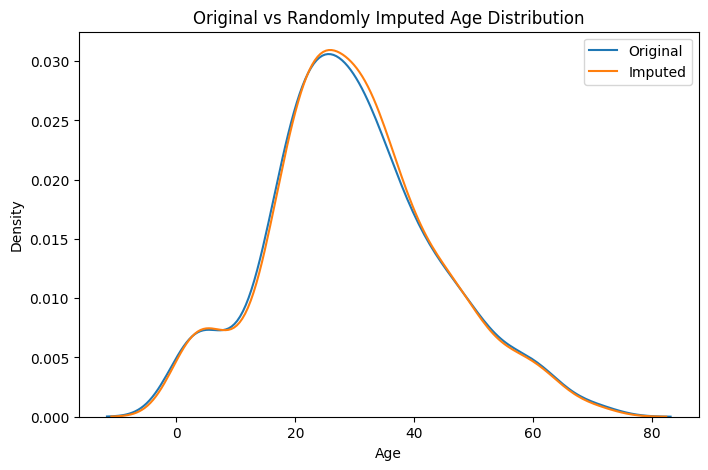

In [ ]:
plt.figure(figsize=(8,5))

# Original Age
sns.kdeplot(X_train['Age'], label='Original', fill=False)

# Imputed Age
sns.kdeplot(X_train['Age_imputed'], label='Imputed', fill=False)

plt.title("Original vs Randomly Imputed Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  197.74779378763094


In [ ]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()   #changed

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,54.859964
Age,71.512440,204.349513,204.349513
Age_imputed,54.859964,204.349513,197.747794


<Axes: >

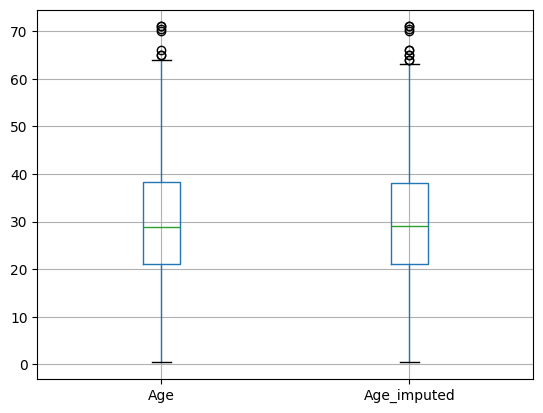

In [ ]:
X_train[['Age', 'Age_imputed']].boxplot()   #no efect on outliers

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving train (1).csv to train (1).csv


In [ ]:
data = pd.read_csv('train (1).csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [ ]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
X = data
y = data['SalePrice']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [ ]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1450,NaN,NaN,136000,NaN,NaN
1269,NaN,TA,144000,TA,NaN
1300,TA,TA,225000,TA,TA
860,Gd,TA,189950,TA,Gd
546,Gd,TA,210000,TA,Gd


In [ ]:
# For X_train
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_train['GarageQual'].dropna().sample(X_train['GarageQual_imputed'].isnull().sum()).values

# For X_test
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_train['GarageQual'].dropna().sample(X_test['GarageQual_imputed'].isnull().sum()).values


In [ ]:
X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu_imputed'].isnull().sum()).values

# For X_test
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu_imputed'].isnull().sum()).values

In [ ]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [ ]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [ ]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.645342
TA,0.412439,0.545455
Fa,0.040917,0.053872
Po,0.027823,0.033670
Ex,0.024550,0.032548


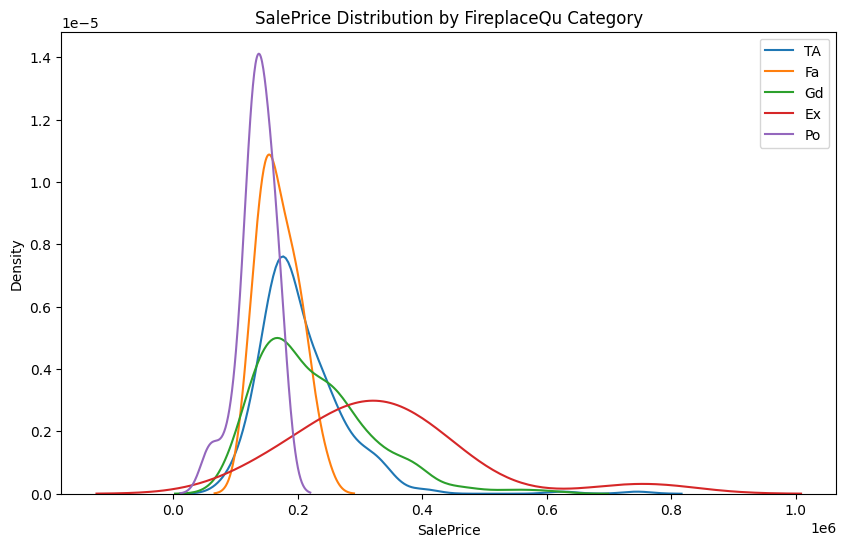

In [ ]:
plt.figure(figsize=(10,6))
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category
    )
plt.title('SalePrice Distribution by FireplaceQu Category')
plt.legend()
plt.show()



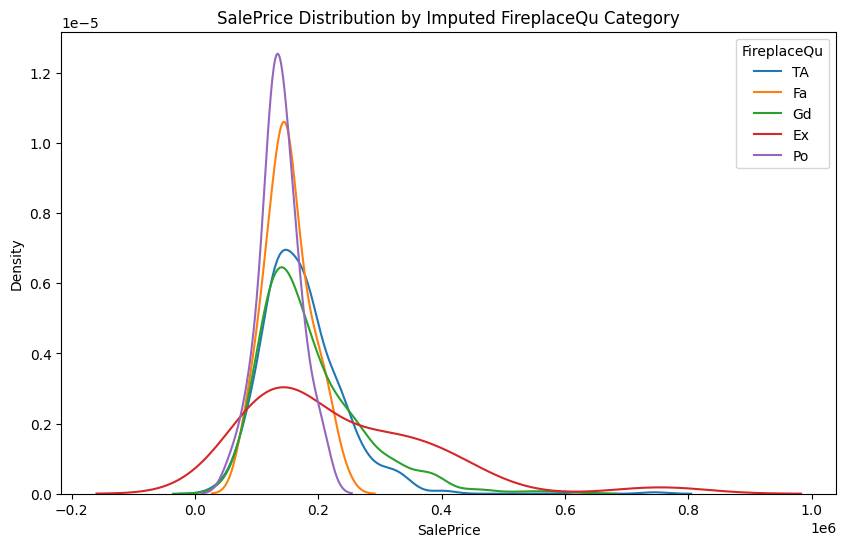

In [ ]:
#not good distribbution
plt.figure(figsize=(10,6))

# Loop through each category in the imputed FireplaceQu column
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu_imputed'] == category],
        x='SalePrice',
        label=category,
        fill=False   # Keep it as a line plot, not filled
    )

plt.title('SalePrice Distribution by Imputed FireplaceQu Category')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.legend(title='FireplaceQu')
plt.show()
